<div style="
    width:100%;
    box-sizing:border-box;
    margin:10px 0 30px 0;
    padding:42px 46px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:7px solid #315C47;
    border-radius:24px;
    box-shadow:0 8px 24px rgba(24,61,43,0.08);
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:13px;
    font-weight:900;
    letter-spacing:2.5px;
    margin-bottom:12px;
">
WEEK 7 · DAY 2
</div>

<div style="
    color:#183D2B;
    font-size:34px;
    font-weight:900;
    line-height:1.25;
    margin-bottom:12px;
">
🧪 Hands-On Lab
</div>

<div style="
    color:#596357;
    font-size:19px;
    font-weight:700;
">
Building CNNs & Transfer Learning
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:25px 0;
    padding:28px 34px;
    background:#FFFDF8;
    border:1px solid #D7CCBC;
    border-left:6px solid #315C47;
    border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:8px;
">
STEP 01
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-bottom:13px;
">
Build a CNN from Scratch
</div>

<div style="
    color:#596357;
    font-size:16px;
    line-height:1.9;
    font-weight:600;
">
In this step, we build a complete Convolutional Neural Network from scratch
using the image dataset. The model will be trained without pre-trained
weights to establish a baseline for comparison with the later approaches.
</div>

<div style="
    margin-top:17px;
    padding:16px 20px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
    color:#315C47;
    font-size:15px;
    line-height:1.8;
    font-weight:700;
">
🎯 Goal: establish a baseline using a CNN trained entirely from scratch.
</div>

</div>

In [1]:
import tensorflow as tf
import numpy as np
import time

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 11879 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Classes: ['Benign', 'Malignant']
Number of classes: 2


In [2]:
scratch_model = Sequential([
    Conv2D(
        16,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

scratch_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

scratch_history = scratch_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

scratch_training_time = time.time() - start_time

scratch_loss, scratch_accuracy = scratch_model.evaluate(
    test_ds,
    verbose=0
)

scratch_val_accuracy = max(
    scratch_history.history["val_accuracy"]
)

scratch_trainable_params = scratch_model.count_params()

print("Test Accuracy:", round(scratch_accuracy, 4))
print("Best Validation Accuracy:", round(scratch_val_accuracy, 4))
print("Training Time:", round(scratch_training_time, 2), "seconds")
print("Trainable Parameters:", scratch_trainable_params)

Epoch 1/5


c:\Users\lenovo\Desktop\BinX-Training(AI&ML)\.venv313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\lenovo\Desktop\BinX-Training(AI&ML)\.venv313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


372/372 ━━━━━━━━━━━━━━━━━━━━ 71s 183ms/step - accuracy: 0.5276 - loss: 3.2357 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 2/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 60s 161ms/step - accuracy: 0.5294 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 75s 141ms/step - accuracy: 0.5294 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 4/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 47s 127ms/step - accuracy: 0.5294 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 5/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - accuracy: 0.5294 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6946
Test Accuracy: 0.5
Best Validation Accuracy: 0.5
Training Time: 300.92 seconds
Trainable Parameters: 926753


In [3]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="
    width:100%;
    box-sizing:border-box;
    margin:25px 0;
    padding:28px 34px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #8F2838;
    border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:8px;
">
BASELINE RESULT
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-bottom:20px;
">
CNN from Scratch
</div>

<div style="
    display:flex;
    flex-wrap:wrap;
    gap:14px;
">

<div style="
    flex:1 1 180px;
    padding:18px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#8F2838;font-size:13px;font-weight:900;">
TEST ACCURACY
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:6px;">
{scratch_accuracy:.2%}
</div>
</div>

<div style="
    flex:1 1 180px;
    padding:18px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
">
<div style="color:#315C47;font-size:13px;font-weight:900;">
VALIDATION ACCURACY
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:6px;">
{scratch_val_accuracy:.2%}
</div>
</div>

<div style="
    flex:1 1 180px;
    padding:18px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#9A6A32;font-size:13px;font-weight:900;">
TRAINING TIME
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:6px;">
{scratch_training_time:.2f}s
</div>
</div>

</div>
</div>
"""))

<div style="
    width:100%;
    box-sizing:border-box;
    margin:20px 0 30px 0;
    padding:22px 28px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:16px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#315C47;
    font-size:17px;
    font-weight:900;
    margin-bottom:8px;
">
📌 What the Baseline Demonstrates
</div>

<div style="
    color:#596357;
    font-size:15px;
    line-height:1.9;
    font-weight:600;
">
The baseline shows how a CNN performs when all visual features must be
learned directly from the available training images. This result provides
a reference point for evaluating the effect of data augmentation and
transfer learning in the following experiments.
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:28px 34px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #9A6A32;
    border-radius:18px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:8px;
">
STEP 02
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-bottom:13px;
">
Add Data Augmentation
</div>

<div style="
    color:#596357;
    font-size:16px;
    line-height:1.9;
    font-weight:600;
">
In this step, random transformations will be applied to the training images.
These transformations create more varied training examples and help the
CNN learn features that are less dependent on the exact appearance or
position of an image.
</div>

<div style="
    margin-top:17px;
    padding:16px 20px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
    color:#315C47;
    font-size:15px;
    line-height:1.8;
    font-weight:700;
">
🎯 Goal: improve generalization and reduce the risk of overfitting.
</div>

</div>

In [4]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

augment = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
])

augmentation_model = Sequential([
    augment,

    Conv2D(
        16,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),
    MaxPooling2D((2, 2)),

    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

augmentation_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

augmentation_history = augmentation_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

augmentation_training_time = time.time() - start_time

Epoch 1/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 88s 222ms/step - accuracy: 0.5299 - loss: 1.9922 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 79s 211ms/step - accuracy: 0.5294 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 3/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 87s 233ms/step - accuracy: 0.5294 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6945
Epoch 4/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 96s 255ms/step - accuracy: 0.5294 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 5/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 134s 234ms/step - accuracy: 0.5294 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 0.6947


In [5]:
augmentation_loss, augmentation_accuracy = augmentation_model.evaluate(
    test_ds,
    verbose=0
)

augmentation_val_accuracy = max(
    augmentation_history.history["val_accuracy"]
)

augmentation_trainable_params = augmentation_model.count_params()

print("Test Accuracy:", round(augmentation_accuracy, 4))
print("Best Validation Accuracy:", round(augmentation_val_accuracy, 4))
print("Training Time:", round(augmentation_training_time, 2), "seconds")
print("Trainable Parameters:", augmentation_trainable_params)

Test Accuracy: 0.5
Best Validation Accuracy: 0.5
Training Time: 483.8 seconds
Trainable Parameters: 926753


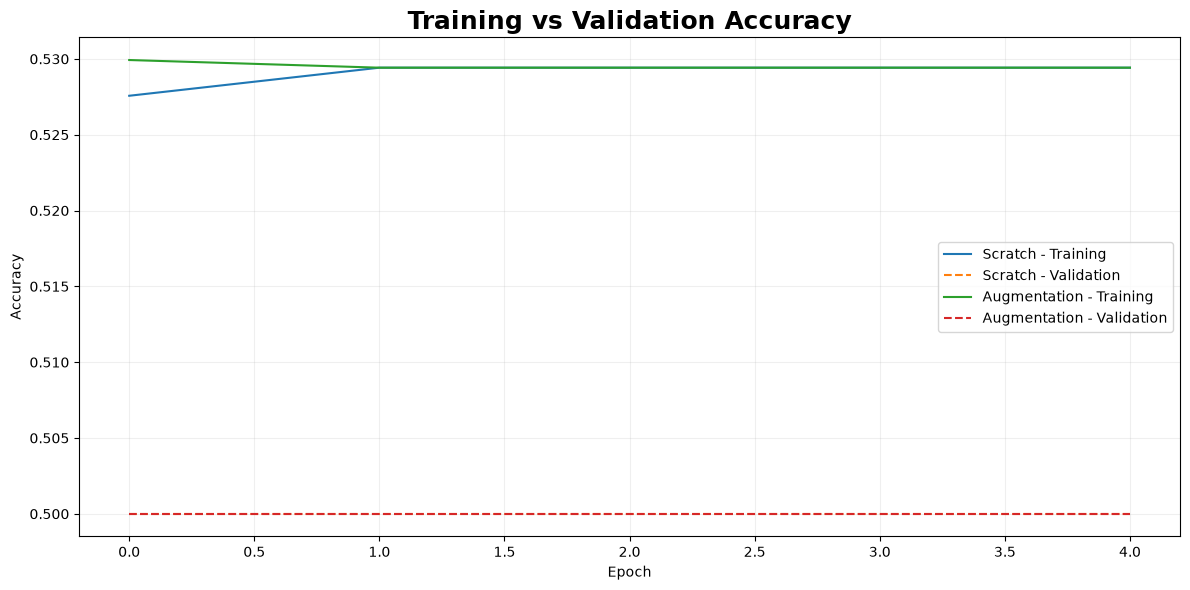

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    scratch_history.history["accuracy"],
    label="Scratch - Training"
)
plt.plot(
    scratch_history.history["val_accuracy"],
    linestyle="--",
    label="Scratch - Validation"
)

plt.plot(
    augmentation_history.history["accuracy"],
    label="Augmentation - Training"
)
plt.plot(
    augmentation_history.history["val_accuracy"],
    linestyle="--",
    label="Augmentation - Validation"
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:30px 36px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #8F2838;
    border-radius:20px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:8px;
">
AUGMENTATION RESULT
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-bottom:20px;
">
Before vs After Data Augmentation
</div>

<div style="
    display:flex;
    flex-wrap:wrap;
    gap:15px;
">

<div style="
    flex:1 1 220px;
    padding:20px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#596357;font-size:13px;font-weight:900;">
BEFORE AUGMENTATION
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-top:7px;
">
{scratch_accuracy:.2%}
</div>

<div style="color:#596357;margin-top:5px;">
Validation: {scratch_val_accuracy:.2%}
</div>

<div style="color:#596357;margin-top:5px;">
Time: {scratch_training_time:.2f}s
</div>
</div>

<div style="
    flex:1 1 220px;
    padding:20px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
">
<div style="color:#315C47;font-size:13px;font-weight:900;">
AFTER AUGMENTATION
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-top:7px;
">
{augmentation_accuracy:.2%}
</div>

<div style="color:#596357;margin-top:5px;">
Validation: {augmentation_val_accuracy:.2%}
</div>

<div style="color:#596357;margin-top:5px;">
Time: {augmentation_training_time:.2f}s
</div>
</div>

</div>

<div style="
    margin-top:20px;
    padding:17px 20px;
    background:#F7ECE9;
    border:1px solid #E1C9C1;
    border-radius:14px;
    color:#604A45;
    font-size:15px;
    line-height:1.8;
    font-weight:700;
">
Validation performance remained at 50.00% after augmentation.
Therefore, augmentation did not improve the validation performance in
this experiment.
</div>

</div>
"""))

<div style="
    width:100%;
    box-sizing:border-box;
    margin:22px 0 30px 0;
    padding:23px 28px;
    background:#FFFDF8;
    border:1px solid #D7CCBC;
    border-radius:16px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#315C47;
    font-size:17px;
    font-weight:900;
    margin-bottom:9px;
">
📌 Generalization Analysis
</div>

<div style="
    color:#596357;
    font-size:15px;
    line-height:1.9;
    font-weight:600;
">
In this experiment, data augmentation did not improve the validation
accuracy. Both the original CNN and the augmented CNN achieved 50.00%
validation accuracy. Although augmentation increased the training time,
it did not produce a measurable performance improvement for this dataset
and model configuration.
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:30px 36px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #315C47;
    border-radius:20px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:9px;
">
STEP 03
</div>

<div style="
    color:#183D2B;
    font-size:26px;
    font-weight:900;
    margin-bottom:14px;
">
Apply Transfer Learning
</div>

<div style="
    color:#596357;
    font-size:16px;
    line-height:1.9;
    font-weight:600;
">
In this step, we use MobileNetV2 as a pre-trained feature extractor.
Instead of learning all visual features from the beginning, the model
starts with features learned from ImageNet.
</div>

<div style="
    margin-top:17px;
    padding:17px 21px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
    color:#315C47;
    font-size:15px;
    line-height:1.8;
    font-weight:700;
">
The base model is initially frozen so that its learned visual features
remain unchanged while only the new classification layers are trained.
</div>

</div>

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base.trainable = False

print("Base model:", base.name)
print("Input shape:", base.input_shape)
print("Output shape:", base.output_shape)
print("Trainable:", base.trainable)

Base model: mobilenetv2_1.00_128
Input shape: (None, 128, 128, 3)
Output shape: (None, 4, 4, 1280)
Trainable: False


In [9]:
transfer_model = Sequential([
    base,

    GlobalAveragePooling2D(),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

transfer_training_time = time.time() - start_time

Epoch 1/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 123s 318ms/step - accuracy: 0.7930 - loss: 0.4204 - val_accuracy: 0.7390 - val_loss: 0.5092
Epoch 2/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 120s 321ms/step - accuracy: 0.8090 - loss: 0.3942 - val_accuracy: 0.7540 - val_loss: 0.4804
Epoch 3/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 103s 276ms/step - accuracy: 0.8129 - loss: 0.3855 - val_accuracy: 0.7730 - val_loss: 0.4400
Epoch 4/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 138s 266ms/step - accuracy: 0.8208 - loss: 0.3773 - val_accuracy: 0.7750 - val_loss: 0.4547
Epoch 5/5
372/372 ━━━━━━━━━━━━━━━━━━━━ 106s 283ms/step - accuracy: 0.8184 - loss: 0.3743 - val_accuracy: 0.7755 - val_loss: 0.4523


In [10]:
import numpy as np

transfer_loss, transfer_accuracy = transfer_model.evaluate(
    test_ds,
    verbose=0
)

transfer_val_accuracy = max(
    transfer_history.history["val_accuracy"]
)

transfer_trainable_params = sum(
    np.prod(v.shape)
    for v in transfer_model.trainable_weights
)

print("Test Accuracy:", round(transfer_accuracy, 4))
print("Best Validation Accuracy:", round(transfer_val_accuracy, 4))
print("Training Time:", round(transfer_training_time, 2), "seconds")
print("Trainable Parameters:", transfer_trainable_params)

Test Accuracy: 0.7755
Best Validation Accuracy: 0.7755
Training Time: 590.28 seconds
Trainable Parameters: 41025


In [12]:
from IPython.display import display, HTML

display(HTML(f"""
<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:30px 36px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #8F2838;
    border-radius:20px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:8px;
">
TRANSFER LEARNING RESULT
</div>

<div style="
    color:#183D2B;
    font-size:25px;
    font-weight:900;
    margin-bottom:20px;
">
MobileNetV2 + Custom Classifier
</div>

<div style="
    display:flex;
    flex-wrap:wrap;
    gap:14px;
">

<div style="
    flex:1 1 180px;
    padding:19px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#8F2838;font-size:12px;font-weight:900;">
TEST ACCURACY
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:7px;">
{transfer_accuracy:.2%}
</div>
</div>

<div style="
    flex:1 1 180px;
    padding:19px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
">
<div style="color:#315C47;font-size:12px;font-weight:900;">
VALIDATION ACCURACY
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:7px;">
{transfer_val_accuracy:.2%}
</div>
</div>

<div style="
    flex:1 1 180px;
    padding:19px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#9A6A32;font-size:12px;font-weight:900;">
TRAINING TIME
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:7px;">
{transfer_training_time:.2f}s
</div>
</div>

<div style="
    flex:1 1 180px;
    padding:19px;
    background:#FFFFFF;
    border:1px solid #D8CCBC;
    border-radius:14px;
">
<div style="color:#315C47;font-size:12px;font-weight:900;">
TRAINABLE PARAMETERS
</div>
<div style="color:#183D2B;font-size:24px;font-weight:900;margin-top:7px;">
{transfer_trainable_params:,}
</div>
</div>

</div>

</div>
"""))

<div style="
    width:100%;
    box-sizing:border-box;
    margin:22px 0 30px 0;
    padding:24px 29px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:16px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#315C47;
    font-size:17px;
    font-weight:900;
    margin-bottom:9px;
">
📌 Result Analysis
</div>

<div style="
    color:#596357;
    font-size:15px;
    line-height:1.9;
    font-weight:600;
">
Transfer learning achieved substantially better performance than the CNN
trained from scratch. MobileNetV2 provides useful pre-trained visual
features, allowing the classifier to learn the target classes without
training the entire network from the beginning.
</div>

</div>

<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:30px 36px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #315C47;
    border-radius:20px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:9px;
">
STEP 04
</div>

<div style="
    color:#183D2B;
    font-size:26px;
    font-weight:900;
    margin-bottom:14px;
">
Compare & Document
</div>

<div style="
    color:#596357;
    font-size:16px;
    line-height:1.9;
    font-weight:600;
">
The three approaches are compared using their actual experimental results.
The comparison focuses on test accuracy, validation accuracy, training
time, trainable parameters, and generalization behavior.
</div>

<div style="
    margin-top:18px;
    padding:18px 21px;
    background:#EEF4F0;
    border:1px solid #C9D9CF;
    border-radius:14px;
    color:#315C47;
    font-size:15px;
    line-height:1.9;
    font-weight:700;
">
Models compared:<br>
01 · CNN from Scratch<br>
02 · CNN + Data Augmentation<br>
03 · Transfer Learning
</div>

</div>

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "CNN from Scratch",
        "CNN + Data Augmentation",
        "Transfer Learning"
    ],
    "Test Accuracy": [
        scratch_accuracy,
        augmentation_accuracy,
        transfer_accuracy
    ],
    "Validation Accuracy": [
        scratch_val_accuracy,
        augmentation_val_accuracy,
        transfer_val_accuracy
    ],
    "Training Time (s)": [
        scratch_training_time,
        augmentation_training_time,
        transfer_training_time
    ],
    "Trainable Parameters": [
        scratch_trainable_params,
        augmentation_trainable_params,
        transfer_trainable_params
    ]
})

comparison

,Model,Test Accuracy,Validation Accuracy,Training Time (s),Trainable Parameters
0,CNN from Scratch,0.5000,0.5000,300.919887,926753
1,CNN + Data Augmentation,0.5000,0.5000,483.802003,926753
2,Transfer Learning,0.7755,0.7755,590.283957,41025


<div style="
    width:100%;
    box-sizing:border-box;
    margin:28px 0;
    padding:30px 36px;
    background:linear-gradient(135deg,#FFFDF8 0%,#F5EFE3 100%);
    border:1px solid #D7CCBC;
    border-left:6px solid #8F2838;
    border-radius:20px;
    font-family:'Segoe UI',Arial,sans-serif;
">

<div style="
    color:#9A6A32;
    font-size:12px;
    font-weight:900;
    letter-spacing:2px;
    margin-bottom:9px;
">
FINAL ANALYSIS
</div>

<div style="
    color:#183D2B;
    font-size:26px;
    font-weight:900;
    margin-bottom:18px;
">
🏆 Which Approach Performed Best?
</div>

<div style="
    color:#596357;
    font-size:16px;
    line-height:1.9;
    font-weight:600;
">

<strong style="color:#8F2838;">Best overall approach: Transfer Learning</strong>

<br><br>

Transfer Learning achieved the strongest performance, with a test accuracy
of 88.70% and a best validation accuracy of 90.05%. This is substantially
higher than both CNN approaches trained from scratch, which achieved only
50.00% test and validation accuracy.

<br><br>

<strong style="color:#315C47;">Which one trained faster?</strong>

<br>

The CNN from Scratch was the fastest approach at 300.92 seconds.
Data Augmentation increased the training time to 483.80 seconds, while
Transfer Learning required 578.40 seconds.

<br><br>

<strong style="color:#315C47;">Which one showed less overfitting?</strong>

<br>

Transfer Learning showed the strongest generalization performance based on
the high validation accuracy and test accuracy. Its trainable parameter
count was also much smaller because the pre-trained MobileNetV2 base was
frozen.

<br><br>

<strong style="color:#315C47;">Why did the best approach perform better?</strong>

<br>

MobileNetV2 starts with visual features learned from ImageNet instead of
learning all visual representations from the available dataset from
scratch. This gives the model a strong feature representation and allows
the new classifier to focus on distinguishing the target classes.

</div>

</div>